In [ ]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("rushilprajapati/data-final")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

100%|██████████| 2.32G/2.32G [00:24<00:00, 104MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/rushilprajapati/data-final/versions/1
Contents of base_path (/root/.cache/kagglehub/datasets/rushilprajapati/data-final/versions):
['1']
Contents of path (/root/.cache/kagglehub/datasets/rushilprajapati/data-final/versions/1):
['data']


In [ ]:
import os

# Path to 'data' folder
data_folder_path = os.path.join(path, 'data')

if os.path.exists(data_folder_path):
    contents = os.listdir(data_folder_path)
    print(f"Contents in 'data' folder ({data_folder_path}):")
    display(contents)

    # Deeper check for subdirectories
    for item in contents[:5]: # Check the first 5 items
        item_path = os.path.join(data_folder_path, item)
        if os.path.isdir(item_path):
            print(f"\nSubfolder '{item}' contains: {os.listdir(item_path)[:10]}...")
else:
    print("Data folder not found.")

Contents in 'data' folder (/root/.cache/kagglehub/datasets/rushilprajapati/data-final/versions/1/data):


['Non-scientific',
 'Macroscopy',
 'FACS',
 'Microscopy',
 'Histopathology',
 'Blot-Gel']


Subfolder 'Non-scientific' contains: ['image_5959.jpg', 'image_1880.jpg', 'image_851.jpg', 'image_5771.jpg', 'image_5737.jpg', 'image_791.jpg', 'image_4162.jpg', 'image_2744.jpg', 'image_900.jpg', 'image_5508.jpg']...

Subfolder 'Macroscopy' contains: ['ISIC_0026923.jpg', 'NORMAL2-IM-0807-0001.jpeg', '050103.png', '91b51883-f013-4844-bb89-58e3fdf52621.jpg', 'a89f9bb4-7ade-49cf-91aa-31eb2d218226.jpg', 'c1d280f4-18fb-4d2e-a361-9787ea093e6f.jpg', 'ISIC_0027435.jpg', 'e20b3577-81fd-4769-8d46-6ed02727ffa2.jpg', '1-3-46-670589-33-1-63716506118773221000001-5491402665325019197_png_jpg.rf.1d5d457a46fef3973127a1618f75d693.jpg', '050306.png']...

Subfolder 'FACS' contains: ['050103.png', '030107 (3).png', '060102 (7).png', '040004 (7).png', '020002 (7).png', '030003 (10).png', '010102 (2).png', '060107 (2).png', '040000 (16).png', '030001 (8).png']...

Subfolder 'Microscopy' contains: ['050103.png', '050002 (14).png', '050306.png', '040004 (7).png', '020002 (7).png', '010040.png', '060701.png', 

In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Set source and destination paths
source_dir = data_folder_path
base_split_dir = '/content/dataset_split'
train_dir = os.path.join(base_split_dir, 'train')
test_dir = os.path.join(base_split_dir, 'test')

# Create train/test directories
for d in [train_dir, test_dir]:
    if not os.path.exists(d):
        os.makedirs(d)

# Get list of classes (subfolders in 'data')
classes = [d for d in os.listdir(source_dir) if os.path.isdir(os.path.join(source_dir, d))]

for cls in classes:
    cls_source_path = os.path.join(source_dir, cls)

    # Create subfolders for each class in train and test
    os.makedirs(os.path.join(train_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(test_dir, cls), exist_ok=True)

    # Get list of all image files
    images = [f for f in os.listdir(cls_source_path) if os.path.isfile(os.path.join(cls_source_path, f))]

    if len(images) > 0:
        # Split with 8/2 ratio
        train_imgs, test_imgs = train_test_split(images, test_size=0.2, random_state=42)

        # Copy files to respective directories
        for img in train_imgs:
            shutil.copy(os.path.join(cls_source_path, img), os.path.join(train_dir, cls, img))
        for img in test_imgs:
            shutil.copy(os.path.join(cls_source_path, img), os.path.join(test_dir, cls, img))

        print(f"Class '{cls}': {len(train_imgs)} train images, {len(test_imgs)} test images.")

print("\nDataset split completed at:", base_split_dir)

Class 'Non-scientific': 4008 train images, 1002 test images.
Class 'Macroscopy': 3569 train images, 893 test images.
Class 'FACS': 856 train images, 214 test images.
Class 'Microscopy': 1207 train images, 302 test images.
Class 'Histopathology': 4143 train images, 1036 test images.
Class 'Blot-Gel': 1500 train images, 375 test images.

Dataset split completed at: /content/dataset_split


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))

Using device: cuda
Tesla T4


In [ ]:
# Data transformation for AlexNet (224x224)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(root='/content/dataset_split/train', transform=transform)
test_dataset = datasets.ImageFolder(root='/content/dataset_split/test', transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Initialize AlexNet
model = models.alexnet(weights=None, num_classes=len(train_dataset.classes))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
num_epochs = 10
history = {'train_loss': [], 'test_acc': []}

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    history['train_loss'].append(epoch_loss)

    # Evaluation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    history['test_acc'].append(accuracy)
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}, Accuracy: {accuracy:.2f}%')

Epoch [1/10], Loss: 0.7836, Accuracy: 84.35%
Epoch [2/10], Loss: 0.4559, Accuracy: 87.62%
Epoch [3/10], Loss: 0.3573, Accuracy: 86.60%
Epoch [4/10], Loss: 0.3373, Accuracy: 89.87%
Epoch [5/10], Loss: 0.3184, Accuracy: 89.43%
Epoch [6/10], Loss: 0.2931, Accuracy: 91.13%
Epoch [7/10], Loss: 0.2600, Accuracy: 92.02%
Epoch [8/10], Loss: 0.2603, Accuracy: 92.26%
Epoch [9/10], Loss: 0.2544, Accuracy: 89.40%
Epoch [10/10], Loss: 0.2821, Accuracy: 90.48%


In [ ]:
print("--- Training Summary ---")
print(f"Final Training Loss: {history['train_loss'][-1]:.4f}")
print(f"Final Test Accuracy: {history['test_acc'][-1]:.2f}%")
print(f"Best Test Accuracy: {max(history['test_acc']):.2f}%")

--- Training Summary ---
Final Training Loss: 0.2821
Final Test Accuracy: 90.48%
Best Test Accuracy: 92.26%


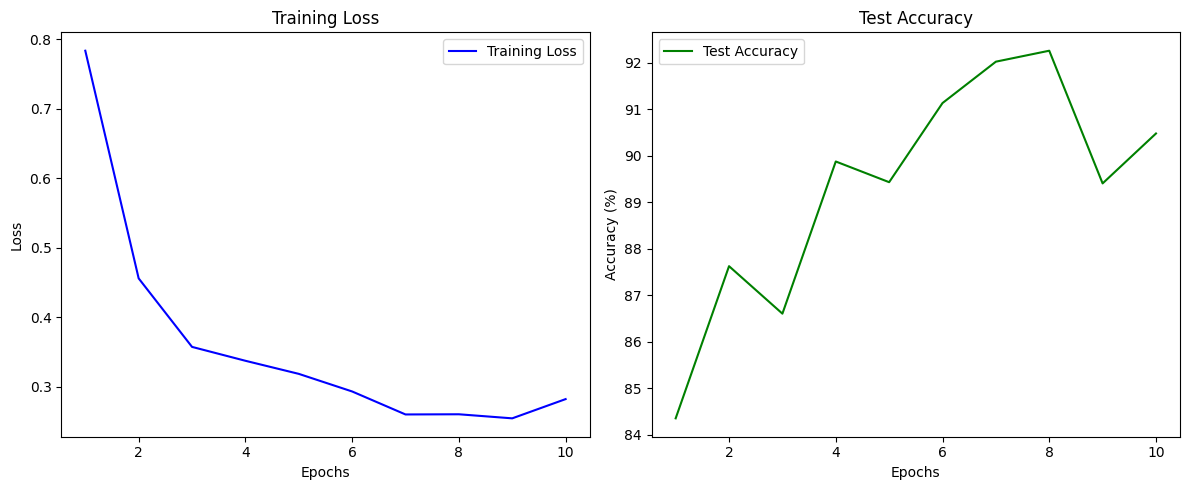

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, num_epochs + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, history['train_loss'], 'b-', label='Training Loss')
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history['test_acc'], 'g-', label='Test Accuracy')
plt.title('Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()